# Image Segmentation with K-Means

This notebook demonstrates **image segmentation**, a key task in computer vision where an image is divided into meaningful regions.

We focus on **K-Means clustering**:
- Implemented both from scratch and using OpenCV's `cv2.kmeans`.
- Groups pixels based on color similarity.
- Helps understand clustering concepts such as centroid initialization, distance computation, and iterative optimization.

The full implementation of our custom K-Means algorithm can be found in `core/clustering/kmeans_algo.py`.

Throughout the notebook, we will:
- Compare the results of the custom K-Means implementation with OpenCV's version.
- Visualize the segmented images and evaluate the differences.

**Bonus:** At the end, we will briefly explore how deep learning-based methods can be used for segmentation, providing a more advanced approach.

In [1]:
# ===============================
# 1. Import libraries
# ===============================
import numpy as np
import cv2
import matplotlib.pyplot as plt

import sys
sys.path.append("..")
from core.clustering.kmeans_algo import kmeans 
from core.utils.visualization import show_two_images, show_image
from core.utils.image_io import load_image

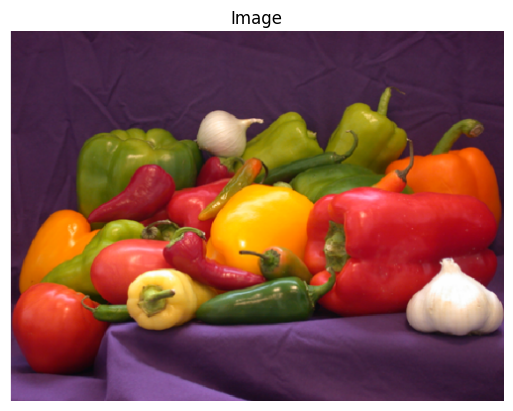

(374, 499, 3)

In [2]:
# ===============================
# 2. Load the image
# ===============================
img_path = "../data/images/"
img = load_image(img_path)

show_image(img)
img.shape

In [3]:
# ===============================
# 3. Reshape the image to a 2D array of pixels and 3 color values (BGR)
# ===============================
data = img.copy()
data = data.reshape((-1,3))     # shape becomes (num_pixel, 3)
data.shape

(186626, 3)

In [4]:
# ===============================
# 4. Convert data to float32, which is required by cv2.kmeans
# ===============================
data = np.float32(data)

In [5]:
# ===============================
# 5. Set the number of clusters (K) -> This is a hyperparameter and could change from one problem to another
# "You can play with this value to see how it will affect the perform
# ===============================
K = 16

**Note:**  

- The below `criteria` is **only for OpenCV's implementation** of K-Means (`cv2.kmeans`).  
- In our **custom KMeans algorithm**, we handle stopping conditions separately:  
  1. `max_iter` → maximum number of iterations  
  2. `epsilon` → minimum change in centroids between iterations  
- The algorithm stops if **either** condition is met.  

So while OpenCV combines both into a single `criteria` parameter, we explicitly pass them as two arguments.

In [6]:
# ===============================
# 5. Define criteria = (type, max_iter, epsilon)
# ===============================
criteria = (cv2.TERM_CRITERIA_MAX_ITER + cv2.TERM_CRITERIA_EPS, 10, 1.0)
# Here, we set:
# - max 10 iterations
# - stop if centroid movement is less than 1.0
max_iter = 10
epsilon = 1.0

### Step: K-Means Segmentation using OpenCV

**Implementation Used:**  
In this step, we are utilizing **OpenCV's built-in K-Means** (`cv2.kmeans`) to perform image segmentation.

**Short Documentation:**  
- `retval, bestLabels, centers = cv2.kmeans(data, K, bestLabels, criteria, attempts, flags, centers=None)`  
  - `data`: Input data points (e.g., pixels reshaped to (num_pixels, 3))
  - `bestLabels`: An output array that stores the cluster labels for each data point. It should be initialized to `None` if you want the                    function to allocate it, or a pre-allocated numpy.ndarray of type np.int32.
  - `K`: Number of clusters  
  - `criteria`: Termination criteria (combination of `cv2.TERM_CRITERIA_MAX_ITER` and `cv2.TERM_CRITERIA_EPS`)  
  - `attempts`: Number of times the algorithm is executed using different initial labellings  
  - `flags`: Method to choose initial centers (`cv2.KMEANS_RANDOM_CENTERS` or `cv2.KMEANS_PP_CENTERS`)  
  - `centers`: Optional initial centers (if any)
    
**References:**  
- [OpenCV K-Means Documentation](https://docs.opencv.org/4.x/d5/d38/group__core__cluster.html)  
- [OpenCV Python K-Means Tutorial](https://docs.opencv.org/4.x/d1/d5c/tutorial_py_kmeans_opencv.html)


In [7]:
np.random.seed(42)
_, labels_cv, centers_cv = cv2.kmeans(data, K, None, criteria, 1, cv2.KMEANS_RANDOM_CENTERS)

### Step: K-Means Segmentation using Custom Implementation

**Implementation Used:**  
In this step, we are using our **custom KMeans function** (`kmeans`) to segment the image.

**Short Documentation:**  
- `labels, means = kmeans(data, K, max_iter=100, epsilon=1)`  
  - `data` (ndarray): Input dataset (M x N matrix)  
      - M = number of data points (samples)  
      - N = number of features per point (e.g., RGB values, coordinates, etc.)  
  - `K` (int): Number of clusters (centroids) to find  
  - `max_iter` (int): Maximum number of iterations to prevent infinite loop  
  - `epsilon` (float): Minimum movement threshold for convergence; the algorithm stops if centroids move less than epsilon between iterations  

- **Returns:**  
  - `means` (ndarray): Final centroids (K x N)  
  - `labels` (ndarray): Cluster assignment for each data point (M,)

**Note:**  
- I tried to **match the OpenCV API as much as possible**.  
  - Input and output are almost similar to OpenCV's `cv2.kmeans`.  
  - OpenCV provides more flexibility and options, such as `attempts` and initialization of centroids, but the **core concept is the same**.   
- The algorithm stops if **either** the maximum iterations are reached **or** centroid movement is below the `epsilon` threshold.  

**Reference:**  
- Full implementation can be found in `core/clustering/kmeans_algo.py`  
- This function is fully implemented from scratch as part of this educational project and is **not optimized for performance** like OpenCV's implementation, so the next line might take few seconds :'(.

In [8]:
np.random.seed(42)
labels_custom, centers_custom = kmeans(data, K, max_iter=10, epislon=1)

**Note:**  
- The output of both implementations — OpenCV's `cv2.kmeans` and our custom `kmeans` function will undergo the **same post-processing steps** since they have similar type and structure.  
- This ensures a fair comparison between the results, such as assigning cluster colors and reshaping the segmented image for visualization.

In [9]:
# -------------------------------
# Post-Processing of K-Means Output
# -------------------------------
# After obtaining the cluster assignments (labels) and centroids (means)
# from either OpenCV or our custom KMeans, we perform the following steps:

# 1. Convert centroids to uint8 (valid image pixel values)
#    This ensures pixel values are integers between 0 and 255
centers_cv = np.uint8(centers_cv)
centers_custom = np.uint8(centers_custom)
# 2. Replace each pixel value with the centroid of its assigned cluster
#    Each pixel in the original image takes the color of its cluster center
segmented_data_cv = centers_cv[labels_cv.flatten()]
segmented_data_custom = centers_custom[labels_custom.flatten()]
# 3. Reshape back to the original image dimensions
#    Converts the 2D array of pixels back to the original shape (height, width, channels)
segmented_img_cv = segmented_data_cv.reshape((img.shape))
segmented_img_custom = segmented_data_custom.reshape((img.shape))
# Note:
# - The post-processing is identical for both OpenCV and custom KMeans outputs
# - This ensures the segmented images are visually comparable side by side

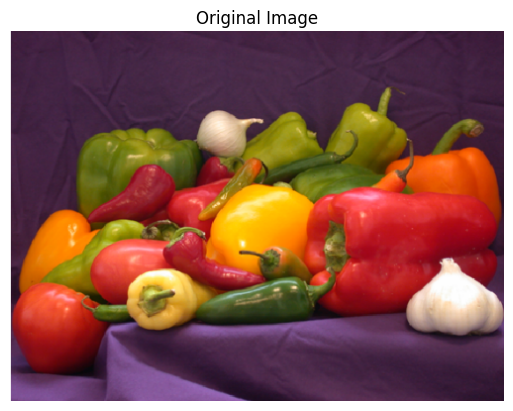

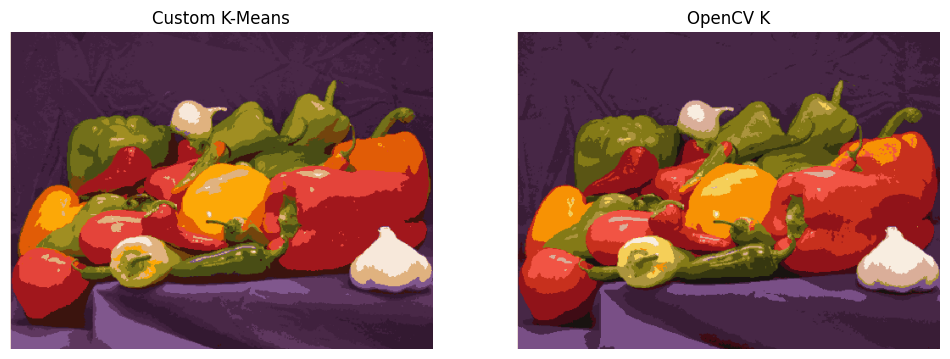

In [10]:
#-------------------------------
# Compare Segmented Images Side by Side
# -------------------------------
# After post-processing the outputs of OpenCV and custom KMeans,
# we want to visually compare the results.

# This step uses matplotlib to display two images next to each other:
# - img1 : Segmented image from OpenCV K-Means
# - img2 : Segmented image from our custom K-Means
# - title1, title2 : Titles for the respective images

# This allows us to quickly see differences and similarities
# between the two implementations.
# Convert images from BGR to RGB
segmented_img_cv = cv2.cvtColor(segmented_img_cv, cv2.COLOR_BGR2RGB)
segmented_img_custom = cv2.cvtColor(segmented_img_custom, cv2.COLOR_BGR2RGB)

show_image(img, "Original Image")
show_two_images(segmented_img_custom, segmented_img_cv, "Custom K-Means", "OpenCV K")



## Observations:  
- Both methods produced very similar segmentation results.  
- Color regions matched well, showing that the custom K-Means correctly assigns pixels and updates centroids.  
- Small differences exist due to initialization or convergence criteria, but overall the results are almost identical.

**Resources**:
- [k-Means Segmentation | Image Segmentation](https://www.youtube.com/watch?v=22mpExWh1LY)  

## Bonus: Image Segmentation with U²-Net

In this section, we explore a deep learning approach to image segmentation using **U²-Net**. Unlike K-Means clustering, which groups pixels based on color similarity, U²-Net directly predicts a **foreground mask** for an image, highlighting regions of interest.  

### Key Points:
- **Model**: U²-Net, a pre-trained deep learning model for salient object detection.  
- **Input**: RGB image, resized to 320×320 for the network.  
- **Output**: A mask of the same resolution as the original image, showing the detected objects.  
- **Workflow**:
  1. Load the pre-trained U²-Net model on CPU.
  2. Preprocess the image (resize, normalize, CHW format).
  3. Forward pass through the network to obtain the mask.
  4. Resize the mask back to the original image dimensions.
  5. Visualize by overlaying the mask on the original image.

### Comparison to K-Means:
While K-Means assigns pixels to clusters based on color similarity, U²-Net produces a direct **segmentation mask**. Both approaches highlight regions of interest, but U²-Net leverages learned features for more accurate object boundaries.

**Reference**:  
- [U²-Net Paper](https://arxiv.org/abs/2005.09007)  
- Implementation available in `models/U-2-Net/model/u2net.py`


In [11]:
import sys
import torch
# Add SAM2 repo to path
sys.path.append("../models/U-2-Net")
from model import U2NET

/home/kammun/Desktop/mylib/build-your-own-cv/notebooks/../models/U-2-Net/model/u2net.py:23: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  src = F.upsample(src,size=tar.shape[2:],mode='bilinear')


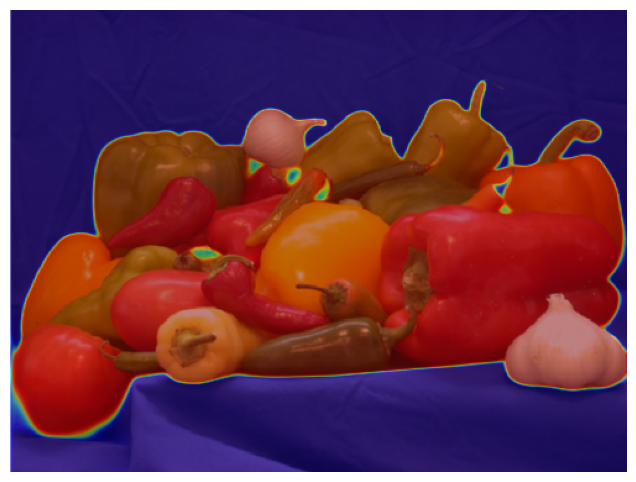

In [12]:

# -------------------------------
# Load model (CPU)
# -------------------------------
model = U2NET(3, 1)  # 3 input channels, 1 output mask
model.load_state_dict(torch.load("../models/U-2-Net/saved_models/u2net/u2net.pth", map_location="cpu"))
model.eval()

# -------------------------------
# Load original image
# -------------------------------
img_orig = cv2.imread(img_path)
img_orig = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)

# -------------------------------
# Preprocess for model
# -------------------------------
img_resized = cv2.resize(img_orig, (320, 320))
img_resized = img_resized / 255.0
img_resized = np.transpose(img_resized, (2, 0, 1))  # HWC -> CHW
img_tensor = torch.from_numpy(img_resized).unsqueeze(0).float()  # shape: [1, 3, 320, 320]

# -------------------------------
# Forward pass
# -------------------------------
with torch.no_grad():
    pred = model(img_tensor)[0][0]  # shape: [320, 320]

# -------------------------------
# Resize mask back to original image size
# -------------------------------
mask = pred.squeeze().numpy()  # ensure 2D
mask = cv2.resize(mask, (img_orig.shape[1], img_orig.shape[0]))  # shape: (H, W)

# -------------------------------
# Visualize
# -------------------------------
plt.figure(figsize=(8, 6))
plt.imshow(img_orig)
plt.imshow(mask, alpha=0.5, cmap="jet")
plt.axis("off")
plt.show()


---

End of notebook. All implementations are detailed in `core/clustering/kmeans_algo.py`.
